<a href="https://colab.research.google.com/github/stylecoff/Breast-cancer-prediction/blob/main/Rifah_BreastCancer_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**The link for my presentation is here!**  
https://www.canva.com/design/DAGMUA53ydo/Y4LhfHdCd3c-CkMP4TOe7w/edit?utm_content=DAGMUA53ydo&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton

# Introduction: Why Breast Cancer?
Breast cancer is the most commonly diagnosed cancer among women around the world. Breast cancer accounts for 12.5% of all new annual cancer cases worldwide, making it the most common cancer in the world with around 30% newly diagnosis each year.

# The Use of Machine Learning  
This problem has to be done manually and is a time consuming process. Therefore, deep learning could be of great help to automatically detect and locate tumor tissue cells and to speed up the process. In order to exploit the full potential one could build a pipeline using massive amounts of tissue image data of various hospitals that were evaluated by different experts. This way one would be able to overcome the dependence on the pathologist/expert on breast cancer which would be especially useful in regions where no experts are available.

**The goal**  
As I started with the analysis on this project, I got an inspiration from my favorite article [Predicting COVID 19 Using X-ray Images](https://medium.com/datadriveninvestor/covid-19-detection-in-x-ray-images-with-pytorch-5c5602b4658f) which is use similar methods to get the prediction and it's good exercise to practice or develop own ML and data science analytics.

#  **Import Necessary Libraries**

In [ ]:
# Import all the necessary libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
from skimage.io import imread
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import numpy as np
import seaborn as sns
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to dataset
data_dir = '/content/drive/MyDrive/Data Repo/Dataset_BUSI_with_GT'

# **Data Preprocessing**

Load and preprocess the images

In [ ]:
# Show some infos about our dataset

benign_dir = os.path.join(data_dir, 'benign')
malignant_dir = os.path.join(data_dir, 'malignant')
normal_dir = os.path.join(data_dir, 'normal')

print('total training benign images:', len(os.listdir(benign_dir)))
print('total training malignant images:', len(os.listdir(malignant_dir)))
print('total training normal images:', len(os.listdir(normal_dir)))

benign_files = os.listdir(benign_dir)
print(benign_files[:10])

malignant_files = os.listdir(malignant_dir)
print(malignant_files[:10])

normal_files = os.listdir(normal_dir)
print(normal_files[:10])

total training benign images: 891
total training malignant images: 421
total training normal images: 266
['benign (10).png', 'benign (102)_mask.png', 'benign (104)_mask.png', 'benign (115).png', 'benign (118).png', 'benign (109)_mask.png', 'benign (110)_mask.png', 'benign (117)_mask.png', 'benign (104).png', 'benign (101).png']
['malignant (126)_mask.png', 'malignant (11)_mask.png', 'malignant (113)_mask.png', 'malignant (140)_mask.png', 'malignant (10)_mask.png', 'malignant (117)_mask.png', 'malignant (131).png', 'malignant (128)_mask.png', 'malignant (137).png', 'malignant (111).png']
['normal (116).png', 'normal (108).png', 'normal (117)_mask.png', 'normal (11).png', 'normal (104).png', 'normal (113)_mask.png', 'normal (114)_mask.png', 'normal (120)_mask.png', 'normal (104)_mask.png', 'normal (11)_mask.png']


Inspecting some of the images to see the variety in the model inputs

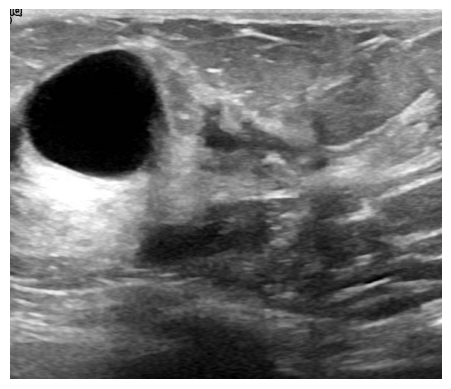

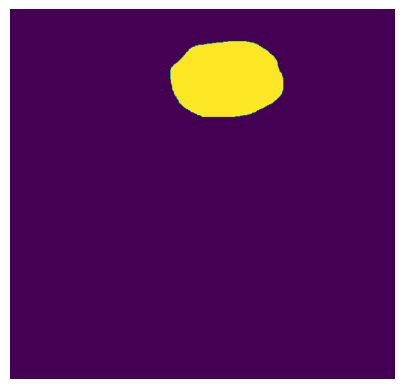

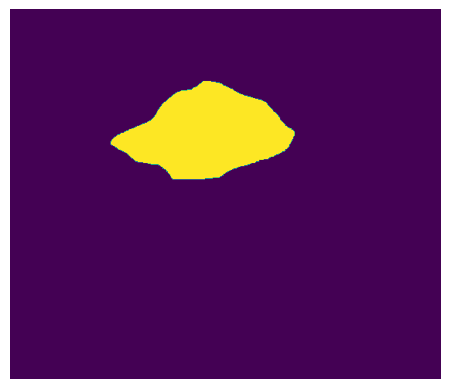

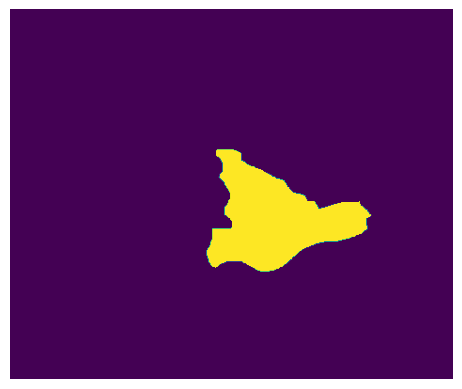

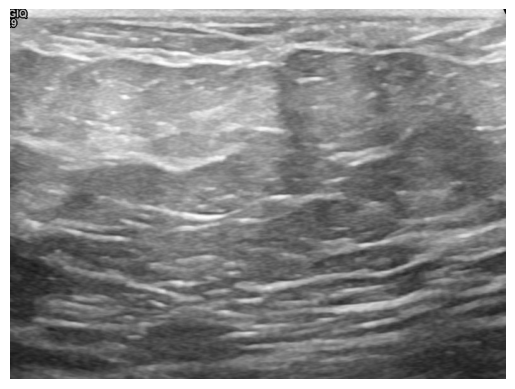

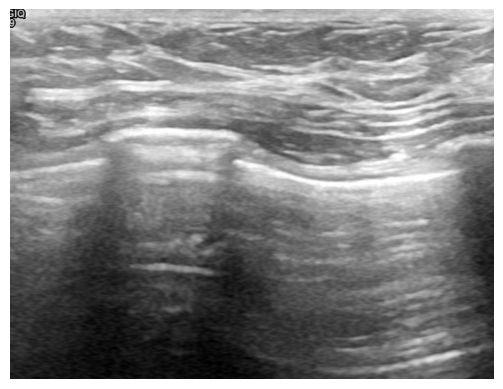

In [ ]:
%matplotlib inline

pic_index = 2

next_benign = [os.path.join(benign_dir, fname)
                for fname in benign_files[pic_index-2:pic_index]]
next_malignant = [os.path.join(malignant_dir, fname)
                for fname in malignant_files[pic_index-2:pic_index]]
next_normal = [os.path.join(normal_dir, fname)
                for fname in normal_files[pic_index-2:pic_index]]

for i, img_path in enumerate(next_benign+next_malignant+next_normal):
  img = mpimg.imread(img_path)
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

Show Benign, Malignant, and Normal images

In [ ]:
# Define a function to load image paths and labels
def load_image_paths_and_labels(data_dir):
    image_paths = []
    labels = []

    for label in ['benign', 'malignant', 'normal']:
        label_dir = os.path.join(data_dir, label)
        for img_name in os.listdir(label_dir):
            if img_name.endswith('.png'):  # Make sure it's an image file
                image_paths.append(os.path.join(label_dir, img_name))
                labels.append(label)

    return image_paths, labels

image_paths, labels = load_image_paths_and_labels(data_dir)

In [ ]:
import pandas as pd

# Optional; create Dataframe to manipulate easier
data = pd.DataFrame({
    'path': image_paths,
    'label': labels
})

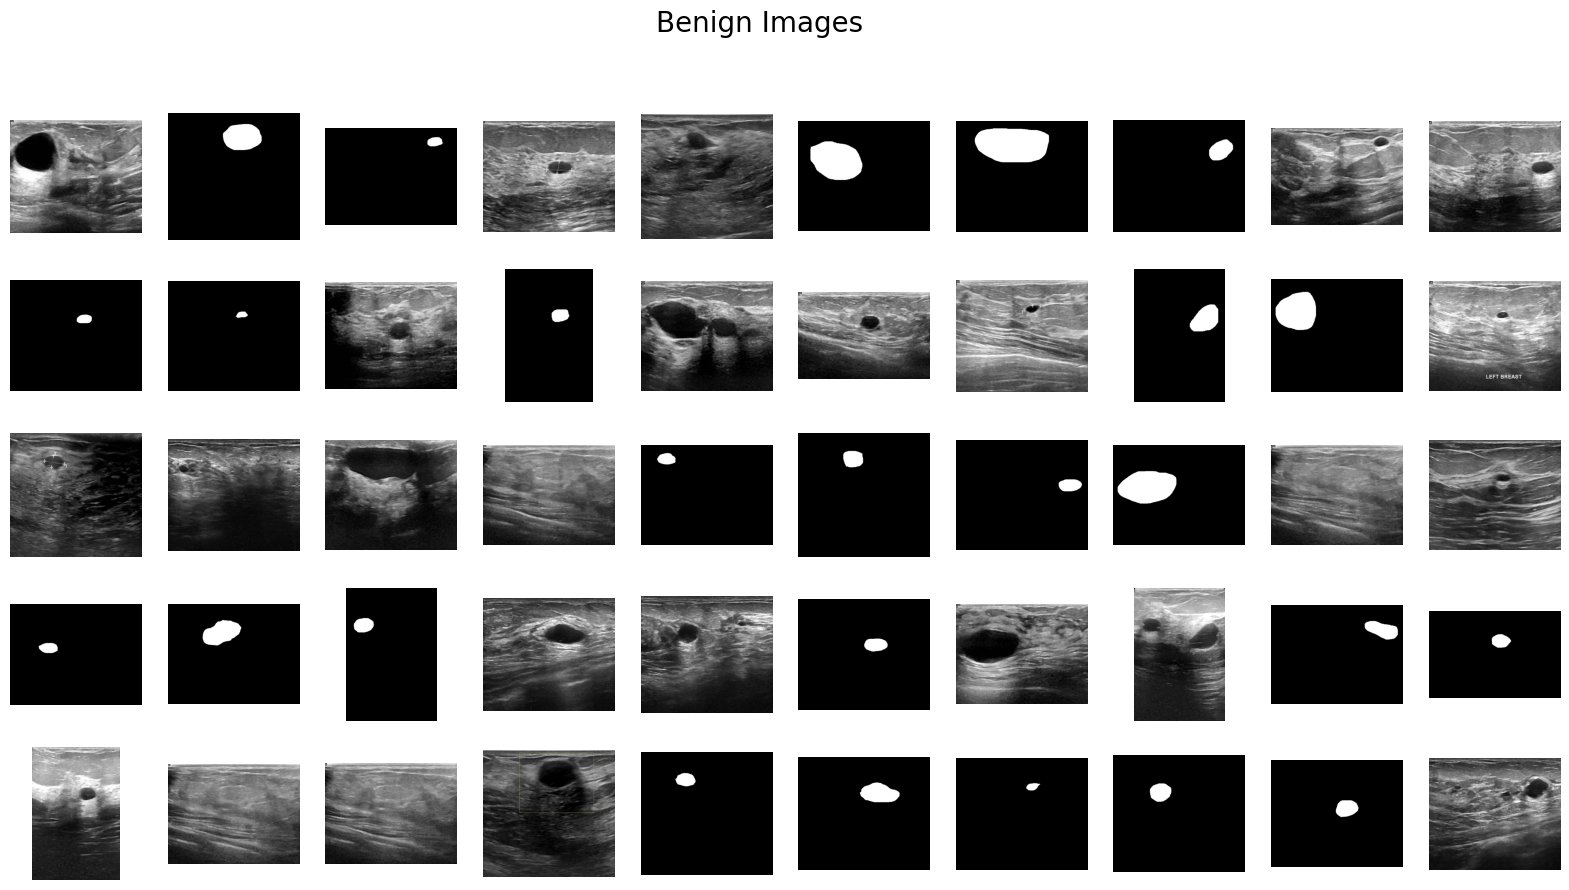

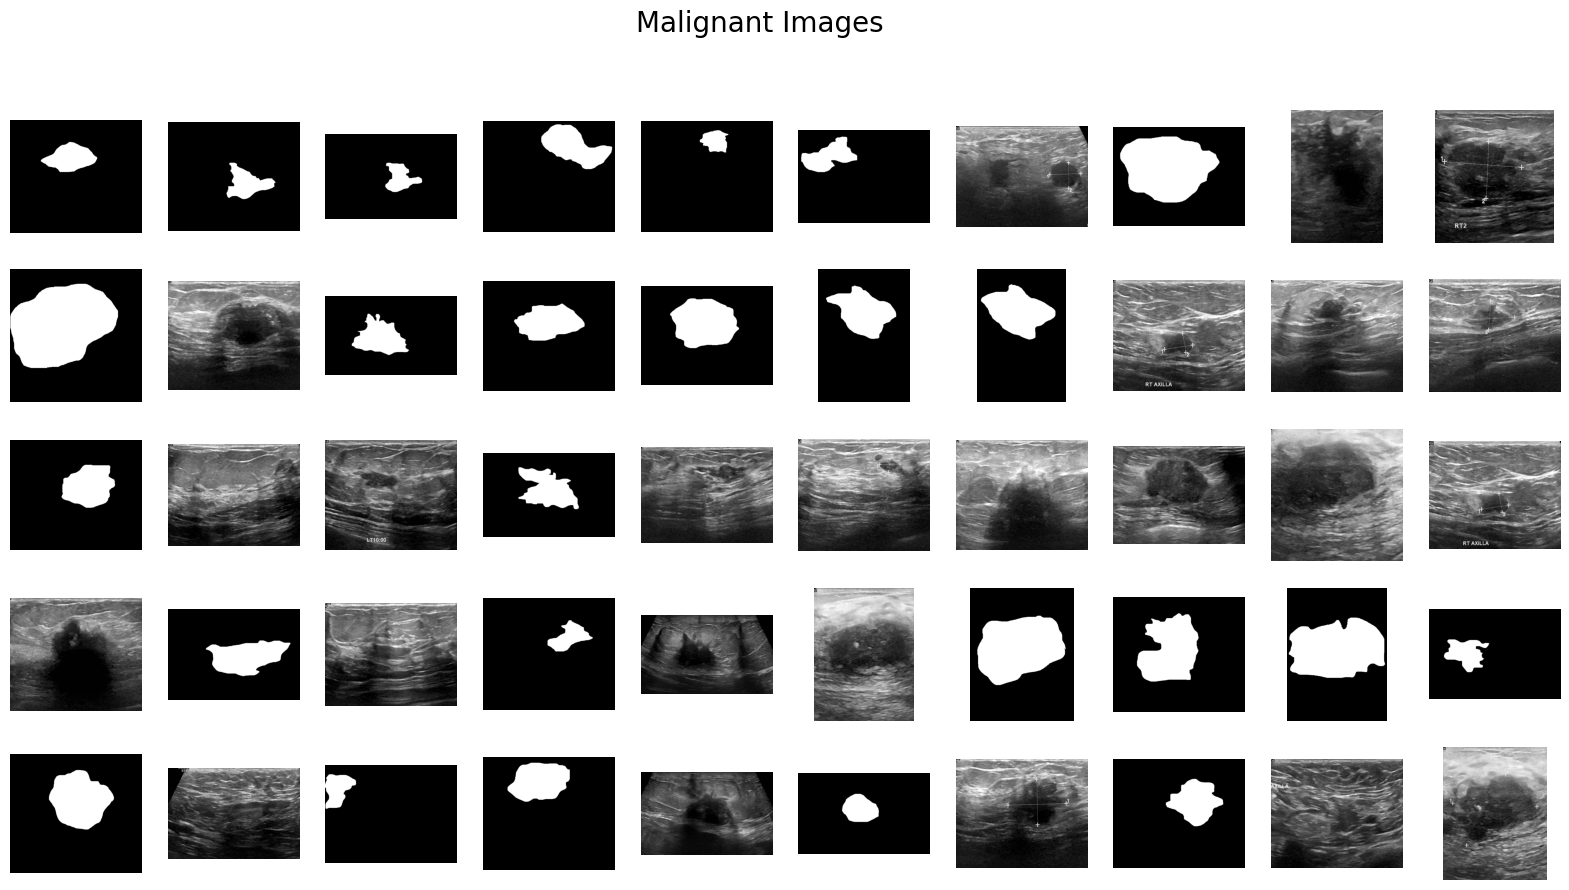

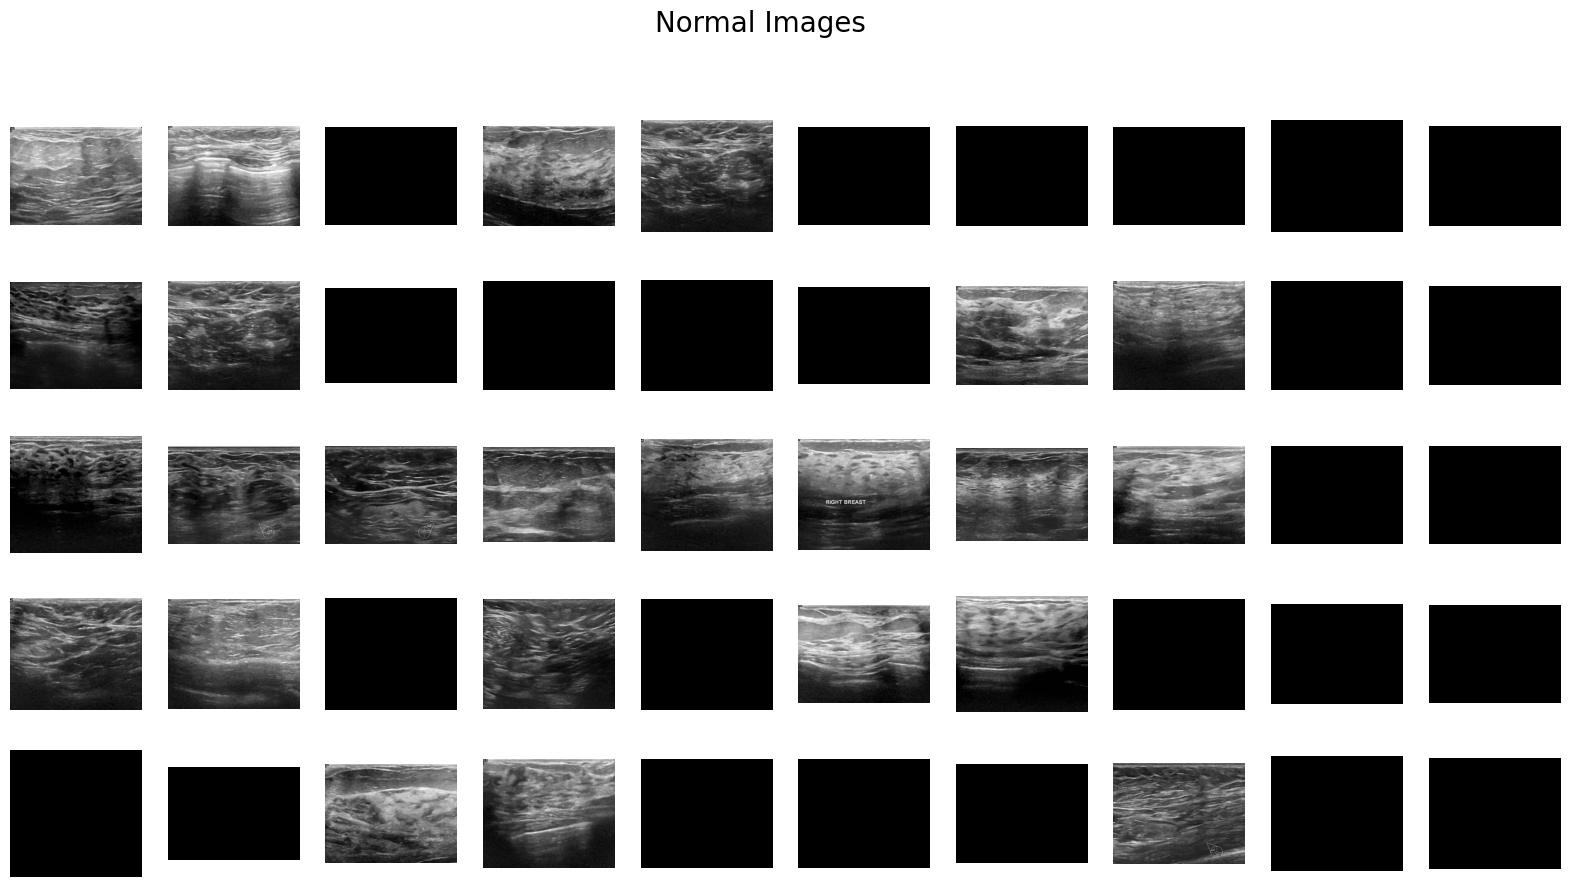

In [ ]:
# Plot the images based on Dataframe
def plot_images(data, label, num_rows, num_cols):
    filtered_data = data[data['label'] == label].reset_index(drop=True) # Filtering the data to only include rows where the 'label' column matches the specified 'label'.
    fig, ax = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 2)) # Create a figure with specified dimensions

    # Looping the grid
    for n in range(num_rows):
        for m in range(num_cols):
            idx = m + num_cols * n # Calculate the index of images in the filtered Dataframe
            if idx < len(filtered_data):
                image_path = filtered_data.loc[idx, 'path']
                image = imread(image_path)
                ax[n, m].imshow(image, cmap='gray')
                ax[n, m].axis('off')

    plt.suptitle(f'{label.capitalize()} Images', fontsize=20)
    plt.show()

# Number of rows and columns to display
num_rows = 5
num_cols = 10

# Plot images for each class
plot_images(data, 'benign', num_rows, num_cols)
plot_images(data, 'malignant', num_rows, num_cols)
plot_images(data, 'normal', num_rows, num_cols)

# **Augmentation**

Rescale pixel values and apply data augmentation techniques like random flip and rotation.

In [ ]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'), # Training exclusive
  tf.keras.layers.RandomRotation(0.2), # Training exclusive
])

Create Tensorflow Datasets for training, validation, and testing

In [ ]:
# Create train, validation, and test datasets
image_shape = (224, 224)

train_dataset = image_dataset_from_directory(data_dir, shuffle=True, batch_size=126,
                                             image_size=image_shape, subset='training',
                                             validation_split=0.3, seed=42)

validation_dataset = image_dataset_from_directory(data_dir, shuffle=True, batch_size=126,
                                                  image_size=image_shape, subset='validation',
                                                  validation_split=0.3, seed=42)

test_dataset = image_dataset_from_directory(data_dir, shuffle=True, batch_size=126,
                                            image_size=image_shape)
# autotune
AUTOTUNE = tf.data.AUTOTUNE

# make train dataset, validation dataset, test dataset
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE) # # buffer size is how much size that you can train at once
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Found 1578 files belonging to 3 classes.
Using 1105 files for training.
Found 1578 files belonging to 3 classes.
Using 473 files for validation.
Found 1578 files belonging to 3 classes.


Found 1578 files belonging to 3 classes.
Using 1263 files for training.
Found 1578 files belonging to 3 classes.
Using 315 files for validation.


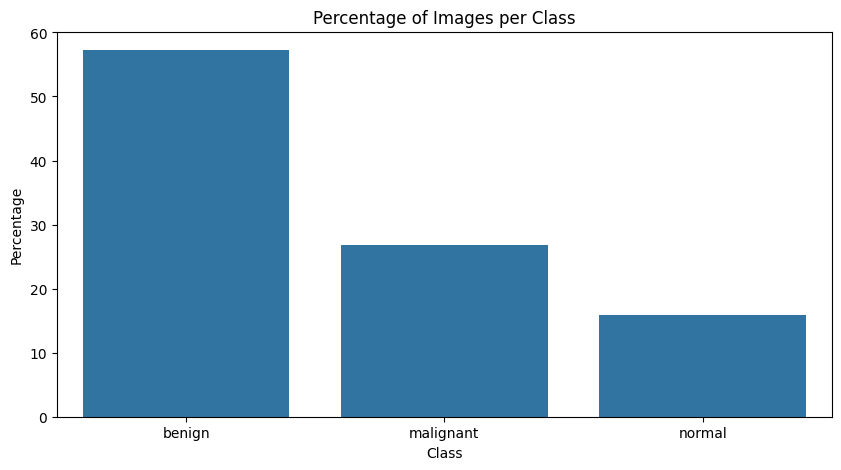

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the path to your dataset directory
data_dir = '/content/drive/MyDrive/Data Repo/Dataset_BUSI_with_GT'
image_size = (224, 224)
batch_size = 126

# Create train, validation, and test datasets
train_dataset_1 = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size
)

validation_dataset_1 = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size
)

# Extract class names
class_names = train_dataset_1.class_names

# Calculate the number of images in each class
class_counts = {}
for class_name in class_names:
    class_counts[class_name] = 0

for images, labels in train_dataset_1:
    for label in labels:
        class_name = class_names[label]
        class_counts[class_name] += 1

# Calculate percentage of images per class
total_images = sum(class_counts.values())
percentages = {class_name: (count / total_images) * 100 for class_name, count in class_counts.items()}

# Plot the percentage of images per class
plt.figure(figsize=(10, 5))
sns.barplot(x=list(percentages.keys()), y=list(percentages.values()))
plt.title('Percentage of Images per Class')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.show()

This shows us imbalanced data when we have a lot of Benign datasets rather than Malignant and Normal images.

# **Model with MobileNetV2 Architecture**

In [ ]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model

# Custom CNN layers
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)

outputs = Dense(3, activation='softmax')(x)

model = Model(inputs, outputs)

learning = 0.0001
init_epochs = 10

model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=learning),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='sparse_categorical_accuracy')])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_2 (TrueDivide)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_2 (Subtract)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │           3,843 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Model Training**

In [ ]:
# Define class weights (example, adjust as needed based on data distribution) due to inbalance input on images
class_weights = {0: 1.0, 1: 2.0, 2: 1.0}

**Implementing callbacks and fitting the model**  
Here we set reduce learning rate and the early stopping to prefent the overfitting.

In [ ]:
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, mode='max', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=5, min_lr=0.001)

history = model.fit(train_dataset, epochs=76, validation_data=validation_dataset,
                    callbacks=[early_stopping, reduce_lr])

Epoch 1/76
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - loss: 1.5539 - sparse_categorical_accuracy: 0.3782 - val_loss: 1.2141 - val_sparse_categorical_accuracy: 0.3953 - learning_rate: 1.0000e-04
Epoch 2/76


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/callback_list.py:96: UserWarning: Learning rate reduction is conditioned on metric `val_accuracy` which is not available. Available metrics are: loss,sparse_categorical_accuracy,val_loss,val_sparse_categorical_accuracy,learning_rate.
  callback.on_epoch_end(epoch, logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 947ms/step - loss: 1.3058 - sparse_categorical_accuracy: 0.4539 - val_loss: 1.1475 - val_sparse_categorical_accuracy: 0.4228 - learning_rate: 1.0000e-04
Epoch 3/76
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - loss: 1.2173 - sparse_categorical_accuracy: 0.5003 - val_loss: 1.0895 - val_sparse_categorical_accuracy: 0.4440 - learning_rate: 1.0000e-04
Epoch 4/76
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 1.2311 - sparse_categorical_accuracy: 0.4919 - val_loss: 1.0311 - val_sparse_categorical_accuracy: 0.4567 - learning_rate: 1.0000e-04
Epoch 5/76
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - loss: 1.1032 - sparse_categorical_accuracy: 0.5498 - val_loss: 0.9799 - val_sparse_categorical_accuracy: 0.4672 - learning_rate: 1.0000e-04
Epoch 6/76
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - loss: 1.0603 - sparse_categorical_accuracy: 0.5471 - val_loss: 0.9287 - val_sparse_categorical_accuracy: 0.4799 - learning_rate: 1.0000e-04
Epoch 7/76
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 995ms/step - loss:

# **Visualizing the accuracy and loss**

**Print the test accuracy**

In [ ]:
# We evaluate the accuracy on our model
test_loss, test_accuracy = model.evaluate(validation_dataset)

# Print the test accuracy in a sentence
print(f'The test accuracy of the model is: {test_accuracy:.2f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 575ms/step - loss: 0.4211 - sparse_categorical_accuracy: 0.8114
The test accuracy of the model is: 0.81


**Plot the model accuracy plot**

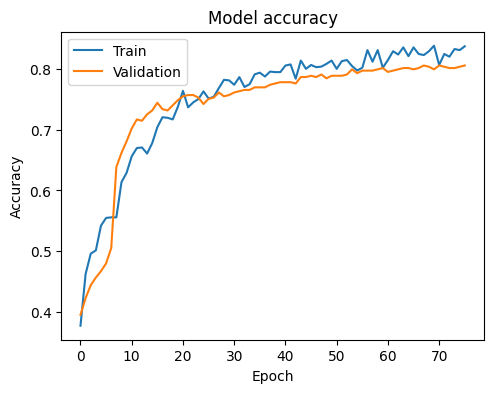

In [ ]:
# Plot the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

Even though here there are some slight divergence, but still this shows us better result with no further overfitting

**Interpretation:**  

The graph shows the model accuracy for 76 epochs for both the training and validation datasets. The training accuracy (blue line) steadily increases, reaching around 86%, while the validation accuracy (orange line) also rises, albeit more slowly, leveling off around 82% (that's actual accuracy and it's validated).

The consistent upward trend in both training and validation accuracy suggests the model is effectively learning and generalizing from the data, though the gap between the two indicates some degree of overfitting may still be present.

**Plot the model loss plot**

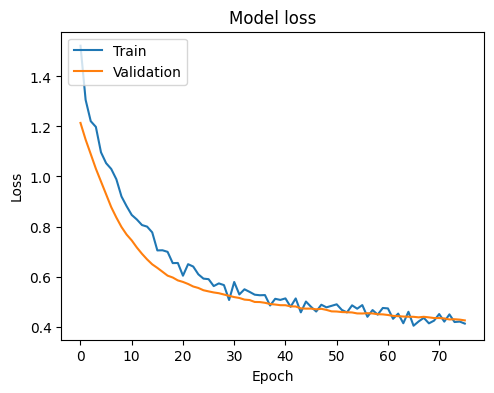

In [ ]:
# Loss Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Interpretation:**

The graph shows the model loss for 76 epochs for both the training and validation datasets. Here I implemented the callbacks such as ReduceLROnPlateau and Early Stopping. With this we prevent lot of noise and overfitting.

The blue line represents the training loss, which consistently decreases, indicating the model is learning from the training data. The orange line represents the validation loss, which also steadily decreases, with less fluctuation compared to the training loss.

This suggests that the model's performance on unseen data is improving over time, though the consistent decrease in both training and validation losses indicates that while the model may not be overfitting, it could still benefit from further tuning to address any remaining generalization issues.

# Comparison with no callback + visualizing the accuracy and loss plots

In [ ]:
# Train the model
history_1 = model.fit(train_dataset, epochs=75, validation_data = validation_dataset, verbose = 1, validation_steps=3)

Epoch 1/75
9/9 ━━━━━━━━━━━━━━━━━━━━ 98s 10s/step - loss: 1.5912 - sparse_categorical_accuracy: 0.3247 - val_loss: 1.0479 - val_sparse_categorical_accuracy: 0.5344
Epoch 2/75
9/9 ━━━━━━━━━━━━━━━━━━━━ 70s 7s/step - loss: 1.3580 - sparse_categorical_accuracy: 0.4289 - val_loss: 1.0968 - val_sparse_categorical_accuracy: 0.5263
Epoch 3/75
9/9 ━━━━━━━━━━━━━━━━━━━━ 99s 9s/step - loss: 1.3836 - sparse_categorical_accuracy: 0.4318 - val_loss: 0.9659 - val_sparse_categorical_accuracy: 0.6190
Epoch 4/75
9/9 ━━━━━━━━━━━━━━━━━━━━ 70s 7s/step - loss: 1.3105 - sparse_categorical_accuracy: 0.4743 - val_loss: 0.9550 - val_sparse_categorical_accuracy: 0.6316
Epoch 5/75
9/9 ━━━━━━━━━━━━━━━━━━━━ 84s 9s/step - loss: 1.2317 - sparse_categorical_accuracy: 0.5307 - val_loss: 0.8874 - val_sparse_categorical_accuracy: 0.6323
Epoch 6/75
9/9 ━━━━━━━━━━━━━━━━━━━━ 182s 14s/step - loss: 1.1820 - sparse_categorical_accuracy: 0.5376 - val_loss: 0.8856 - val_sparse_categorical_accuracy: 0.6000
Epoch 7/75
9/9 ━━━━━━━━━━

In [ ]:
# We evaluate the accuracy on our model
test_loss, test_accuracy = model.evaluate(validation_dataset)

# Print the test accuracy in a sentence
print(f'The test accuracy of the model is: {test_accuracy:.2f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 37s 6s/step - loss: 0.4140 - sparse_categorical_accuracy: 0.7996
The test accuracy of the model is: 0.81


Here we can see that the accuracy is same (but it should be higher than this). It because we don't set up the callback function to stop early. Why it still same? because we always re run the same model. It is also often leads to overfitting. Let's plot it to see what we've been doing!

**Plot the model accuracy plot**

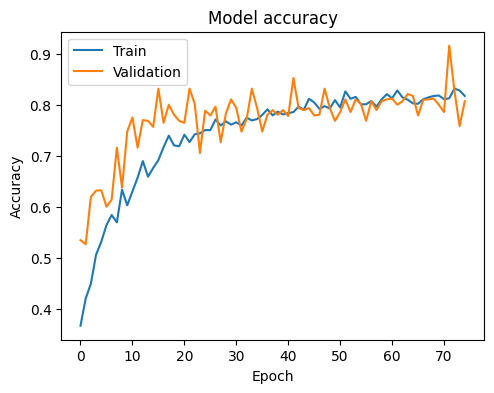

In [ ]:
# Plot the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_1.history['sparse_categorical_accuracy'])
plt.plot(history_1.history['val_sparse_categorical_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

Here, I didn't set the early stopping and let my model ran until the last epochs (75 epochs) non stop. We can see there are many noises and it indicates as overfitting.

**Interpretation:**

The graph suggests potential overfitting as the validation accuracy fluctuates significantly while the training accuracy shows a steadier, upward trend.

Despite achieving an 85% accuracy, the high variability in validation accuracy indicates the model may not generalize well to unseen data. The dataset's imbalance, with more benign samples than malignant and normal ones, could contribute to this issue.

**Plot Model Loss**

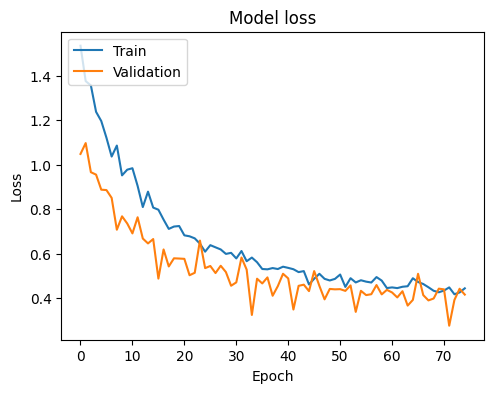

In [ ]:
# Loss Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')

plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Interpretation:**

This graph illustrates the training and validation loss of a model 75 epochs. The x-axis represents the number of epochs, while the y-axis indicates the loss values.

Initially, both training and validation loss values fluctuate significantly, with the validation loss showing higher variability throughout the training process. Over time, the training loss gradually decreases and stabilizes, indicating that the model is learning and improving its performance on the training data. The validation loss also shows a general downward trend but with more fluctuations, suggesting variability in model performance on unseen data.

Overall, the plot shows the model's ability to reduce loss over time, though the fluctuations in validation loss highlight the challenges of achieving consistent performance on validation data.

# **Exploratory Analysis**

What do we know about our data

In [ ]:
# import some libraries for data visualization
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [ ]:
# Confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
# ROC curve
def plot_roc_curve(y_true, y_pred_prob, num_classes):
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true, y_pred_prob[:, i], pos_label=i)
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(8, 6))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
# Generate the prediction
# Assuming test_dataset is already created and model is trained
y_true = []
y_pred = []
y_pred_prob = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_pred_prob.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_prob = np.array(y_pred_prob)

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 768ms/step


**Plotting**

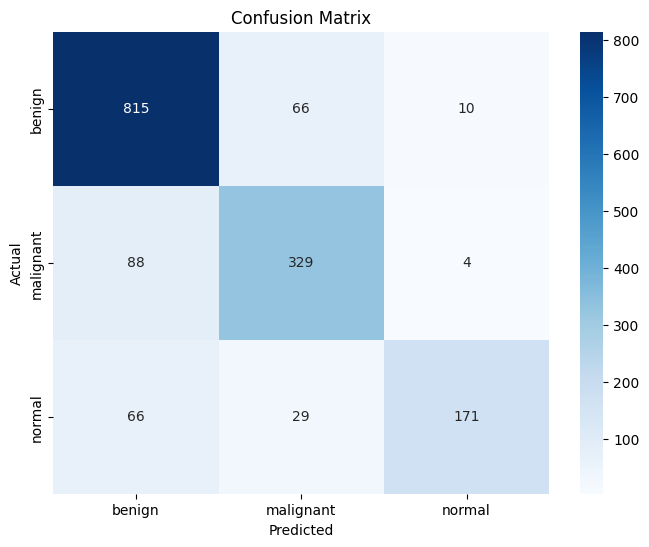

In [ ]:
# This will show the confusion matrics
class_names = ['benign', 'malignant', 'normal']
plot_confusion_matrix(y_true, y_pred, class_names)

The matrix reveals that 815 benign instances were correctly predicted as benign, 66 benign instances were incorrectly predicted as malignant, and 10 benign instances were incorrectly predicted as normal. For malignant instances, 329 were correctly predicted as malignant, while 88 were incorrectly predicted as benign, and 4 were incorrectly predicted as normal. For normal instances, 171 were correctly predicted as normal, 66 were incorrectly predicted as benign, and 29 were incorrectly predicted as malignant.

The overall distribution of values in the matrix provides insight into the performance of the classifier, highlighting its accuracy in predicting each class and where misclassifications occur.

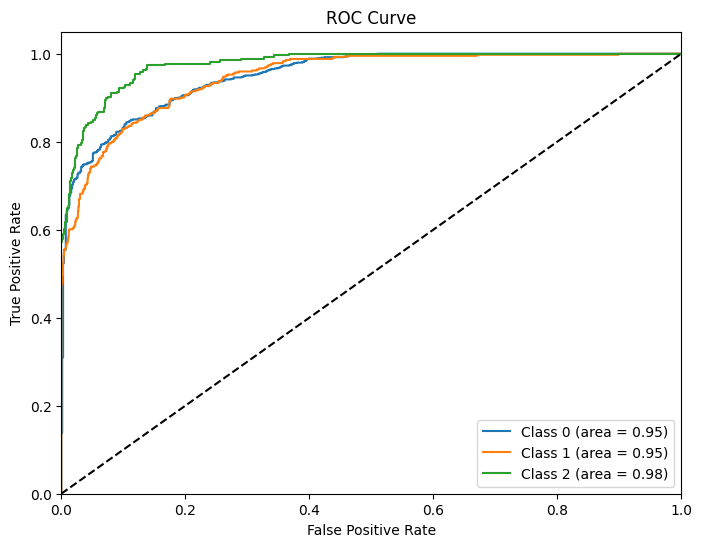

In [ ]:
# This will show the ROC Curve
plot_roc_curve(y_true, y_pred_prob, num_classes=len(class_names))

The plot includes three curves for Class 0, Class 1, and Class 2. Each curve represents the classifier's performance in distinguishing that specific class from the others. The Area Under the Curve (AUC) for each class is provided in the legend, with Class 0 and Class 1 both having an AUC of 0.96, and Class 2 having an AUC of 0.98. These high AUC values indicate strong performance for all three classes.

The diagonal dashed line represents the performance of a random classifier with an AUC of 0.5. Curves above this line demonstrate better-than-random performance. Overall, this ROC curve suggests that the classifier performs well in distinguishing between the three classes.

# **Model Prediction**

In [ ]:
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

# Define the class labels
class_labels = ["Malignant", "Benign", "Healthy"]

uploaded = files.upload()

for fn in uploaded.keys():
    # predicting images
    path = fn
    img = load_img(path, target_size=(224, 224))  # Adjust target_size to (224, 224)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocess the image in the same way as during training
    x = x / 255.0  # Normalization, if this was used during training

    images = np.vstack([x])
    predictions = model.predict(images, batch_size=1)  # Use batch_size=1 for single image prediction

    # Assuming model output is probabilities for classification
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_label = class_labels[predicted_class_index]
    prediction_probability = predictions[0][predicted_class_index]

    print(f'Filename: {fn}')
    print(f'Predicted Class: {predicted_label}')
    print(f'Prediction Probability: {prediction_probability:.2f}')
    print(f'Full Prediction Probabilities: {predictions[0]}')

Saving benign (5).png to benign (5).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Filename: benign (5).png
Predicted Class: Healthy
Prediction Probability: 0.98
Full Prediction Probabilities: [0.00988313 0.01187669 0.9782402 ]


**Note: [(Benign, Malignant, Normal)]**

**What's Happen Here?**

The incorrect prediction, where an image labeled "benign" is predicted as "Healthy," could be due to several factors. If the model's training data is imbalanced or insufficient, it might cause the model to become biased or fail to learn distinct features for each class. Additionally, issues with the model architecture, such as overfitting or underfitting, can affect performance, especially if the model is either too complex or too simple for the task. Inconsistent preprocessing, where the steps applied during prediction differ from those during training, or differences in image quality, can also lead to misclassification. Moreover, if the classes have significant overlap or similarity, the model might struggle to differentiate them. To address these issues, review the training data for balance and representativeness, ensure preprocessing steps are consistent, and evaluate the model's performance on a validation set to identify and correct any discrepancies.

# **Closing**  
In summary, the current model's performance is inadequate, because there are incorrect predictions and signs of overfitting in both training. While the current model shows promise, it needs further refinement and validation to be truly effective and reliable in a healthcare setting. Addressing the identified issues through data augmentation, balancing, and architectural improvements will be crucial steps toward making this model a valuable tool in breast cancer diagnosis and potentially other medical applications.